<a href="https://colab.research.google.com/github/pamritha25/ML-and-DL-Projects/blob/main/churn%20prediction/Churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **churn prediction dataset**



**Problem statement**



Customer churn is one of the most critical challenges faced by banks today. Losing an existing customer is often more costly than acquiring a new one, because it not only reduces revenue but also diminishes long-term customer loyalty and the potential for cross-selling financial products. Understanding which customers are likely to leave allows banks to take proactive measures, such as personalized offers, loyalty programs, or targeted interventions, to retain high-value clients.

The aim of this project is to leverage machine learning techniques to analyze customer data and predict the likelihood of a customer exiting the bank. By developing predictive models, the bank can identify at-risk customers before they churn and implement data-driven retention strategies, ultimately improving customer satisfaction and profitability.

The dataset used for this project contains 165,034 customer records, with a rich mix of demographic, financial, and account-related features. The target variable, Exited, indicates whether a customer has left the bank (1) or remained active (0).

In [ ]:

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
df=pd.read_csv("/churn prediction.csv")

In [ ]:
df.head(10)

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0
5,5,15771669,Genovese,588,Germany,Male,36.0,4,131778.58,1,1.0,0.0,136024.31,1
6,6,15692819,Ch'ang,593,France,Female,30.0,8,144772.69,1,1.0,0.0,29792.11,0
7,7,15669611,Chukwuebuka,678,Spain,Male,37.0,1,138476.41,1,1.0,0.0,106851.60,0
8,8,15691707,Manna,676,France,Male,43.0,4,0.00,2,1.0,0.0,142917.13,0
9,9,15591721,Cattaneo,583,Germany,Male,40.0,4,81274.33,1,1.0,1.0,170843.07,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

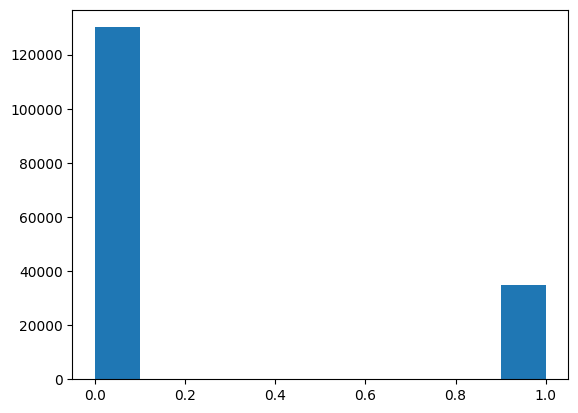

In [ ]:
plt.hist(df["Exited"])
plt.show()

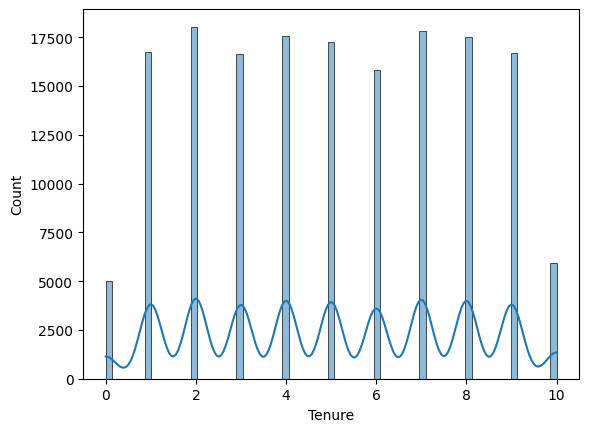

In [ ]:
sns.histplot(df["Tenure"],kde=True)
plt.show()

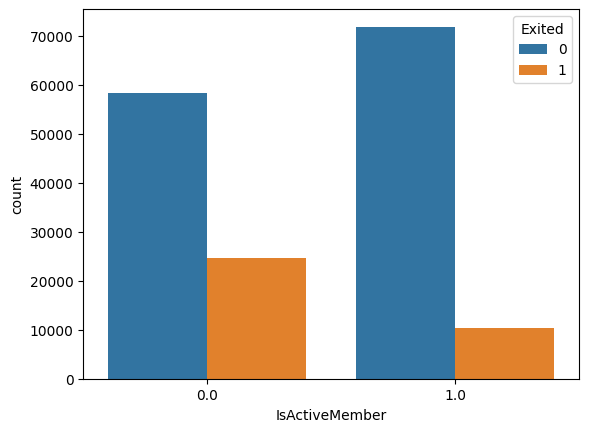

In [ ]:
sns.countplot(data=df, x="IsActiveMember", hue='Exited')
plt.show()

<Axes: xlabel='Geography', ylabel='Exited'>

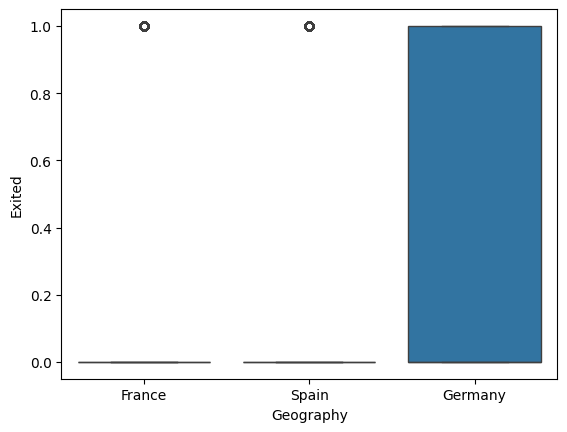

In [ ]:
sns.boxplot(x='Geography', y='Exited', data=df)

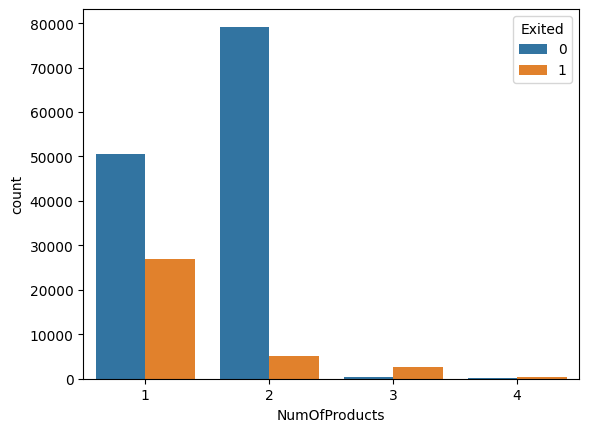

In [ ]:
sns.countplot(data=df, x="NumOfProducts", hue='Exited')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB


In [ ]:
print(df["Gender"].unique())

['Male' 'Female']


In [ ]:
print(df["Geography"].unique())

['France' 'Spain' 'Germany']


In [ ]:
print(df["Surname"].unique())

['Okwudilichukwu' 'Okwudiliolisa' 'Hsueh' ... 'Aliyev' 'McMinn' 'Elkins']


In [ ]:
df.isnull().sum()

,0
id,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Geography']=le.fit_transform(df['Geography'])
df['Surname']=le.fit_transform(df['Surname'])


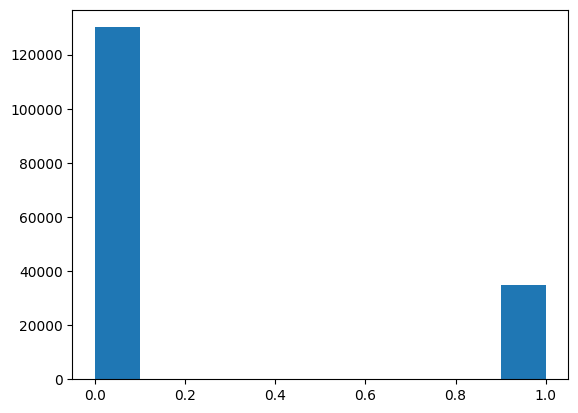

In [ ]:
plt.hist(df["Exited"])
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE

X = df.drop("Exited", axis=1)
y = df["Exited"]

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

In [ ]:
import pandas as pd
df_cleaned = pd.concat(
    [pd.DataFrame(X_smote, columns=X.columns),
     pd.Series(y_smote, name="Exited")],
    axis=1
)
df=df_cleaned

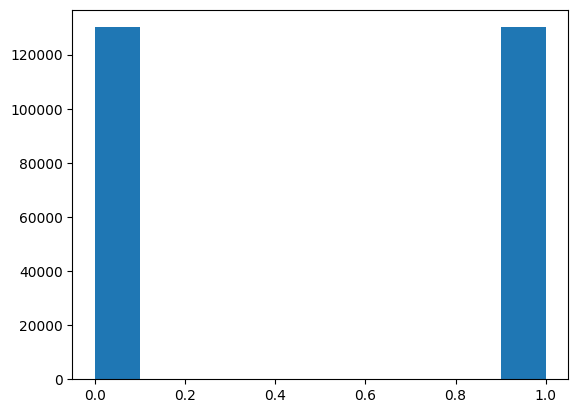

In [ ]:
plt.hist(df["Exited"])
plt.show()

**correlation matrix**

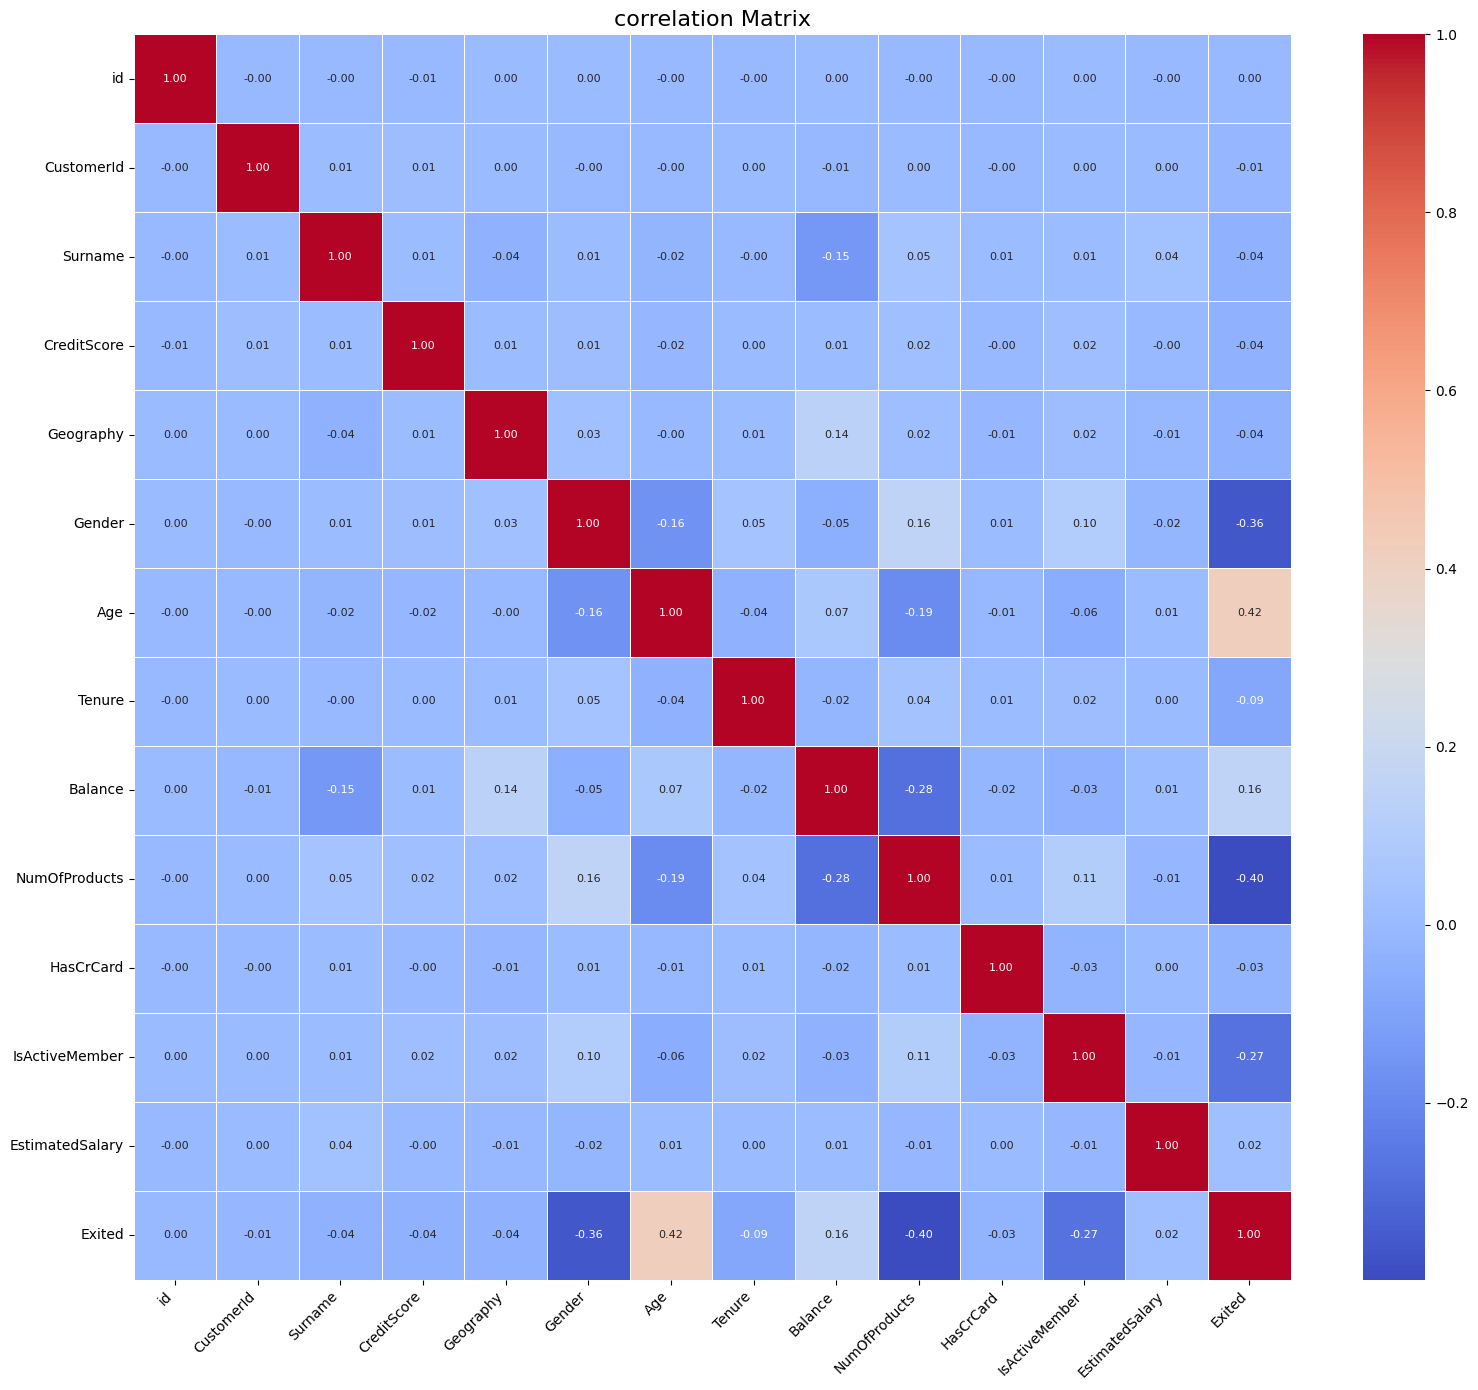

In [ ]:
plt.figure(figsize=(16,14))
corr_matrix=df.corr(numeric_only=True)
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5,annot_kws={"size":8})
plt.title("correlation Matrix",fontsize=16)
plt.xticks(rotation=45,ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

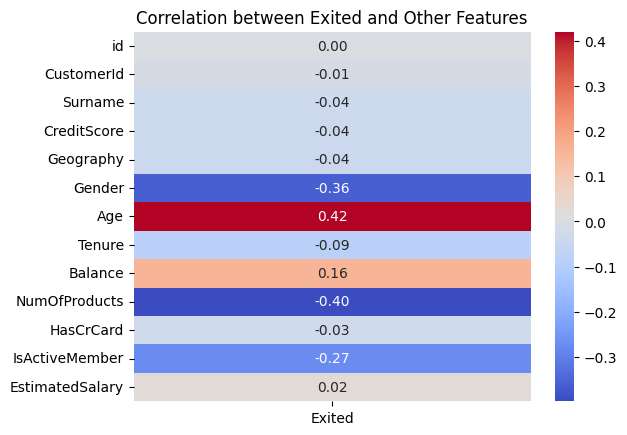

In [ ]:
survived_corr = df.corr()['Exited']


survived_corr = survived_corr.drop('Exited')


sns.heatmap(survived_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation between Exited and Other Features')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260226 entries, 0 to 260225
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               260226 non-null  int64  
 1   CustomerId       260226 non-null  int64  
 2   Surname          260226 non-null  int64  
 3   CreditScore      260226 non-null  int64  
 4   Geography        260226 non-null  int64  
 5   Gender           260226 non-null  int64  
 6   Age              260226 non-null  float64
 7   Tenure           260226 non-null  int64  
 8   Balance          260226 non-null  float64
 9   NumOfProducts    260226 non-null  int64  
 10  HasCrCard        260226 non-null  float64
 11  IsActiveMember   260226 non-null  float64
 12  EstimatedSalary  260226 non-null  float64
 13  Exited           260226 non-null  int64  
dtypes: float64(5), int64(9)
memory usage: 27.8 MB


In [ ]:
df.drop(["id","CustomerId","Surname","CreditScore","Geography","HasCrCard","EstimatedSalary"],axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260226 entries, 0 to 260225
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Gender          260226 non-null  int64  
 1   Age             260226 non-null  float64
 2   Tenure          260226 non-null  int64  
 3   Balance         260226 non-null  float64
 4   NumOfProducts   260226 non-null  int64  
 5   IsActiveMember  260226 non-null  float64
 6   Exited          260226 non-null  int64  
dtypes: float64(3), int64(4)
memory usage: 13.9 MB


*outlier checking**

<Axes: >

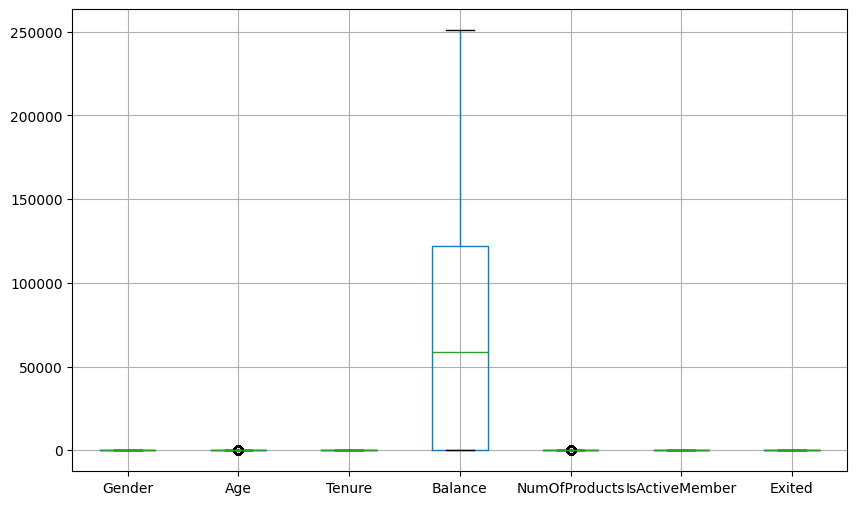

In [ ]:
plt.figure(figsize=(10,6))
df.boxplot()

In [ ]:

def remove_outliers_iqr(df, exclude_column):
    for col in df.columns:

        if col == exclude_column:
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df


df_cleaned = remove_outliers_iqr(df, exclude_column='Exited')
df=df_cleaned

**data scaling**

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler



features = ["Gender","Age","Tenure","Balance","NumOfProducts","IsActiveMember"]

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[features])

scaled_df = pd.DataFrame(scaled_data, columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd


X = df[["Gender","Age","Tenure","Balance","NumOfProducts","IsActiveMember"]]
y = df[["Exited"]]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


model = LogisticRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Baseline model accuracy: 0.80


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
df.head(10)

,Gender,Age,Tenure,Balance,NumOfProducts,IsActiveMember,Exited
0,1,33.0,3,0.00,2,0.0,0
1,1,33.0,1,0.00,2,1.0,0
2,1,40.0,10,0.00,2,0.0,0
3,1,34.0,2,148882.54,1,1.0,0
4,1,33.0,5,0.00,2,1.0,0
5,1,36.0,4,131778.58,1,0.0,1
6,0,30.0,8,144772.69,1,0.0,0
7,1,37.0,1,138476.41,1,0.0,0
8,1,43.0,4,0.00,2,0.0,0
9,1,40.0,4,81274.33,1,1.0,0


In [ ]:
model.predict([[1, 36.0, 4, 131778.58, 1, 0.0]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.88


In [ ]:
from sklearn.svm import SVC

svclassifier = SVC(
    kernel="linear",
    cache_size=2000,
    max_iter=5000,
    random_state=42
)

svclassifier.fit(X_train, y_train)
svclassifier.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


0.4184351887894122

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model =RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Baseline model accuracy: 0.88


In [ ]:
from sklearn.model_selection import KFold
kf=KFold(n_splits=8,shuffle=True,random_state=42)
model=LogisticRegression()
best_accuracy = 0
best_fold = -1
best_X_train = None
best_y_train = None
best_X_test = None
best_y_test = None
best_y_pred = None
for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Fold {fold} Accuracy: {acc}")

    if acc > best_accuracy:
        best_accuracy = acc
        best_fold = fold
        best_X_train = X_train
        best_y_train = y_train
        best_X_test = X_test
        best_y_test = y_test
        best_y_pred = y_pred
print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 1 Accuracy: 0.8055304705259552


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel

Fold 2 Accuracy: 0.8061532712608601


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Fold 6 Accuracy: 0.8101021425012457


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Fold 7 Accuracy: 0.8055555555555556
Fold 8 Accuracy: 0.8002927254608869

 Best Fold: 6 with Accuracy: 0.8101021425012457


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
model = LogisticRegression()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8101021425012457

In [ ]:
model=DecisionTreeClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.8785189337319382

In [ ]:
model=RandomForestClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.8843423019431988

**DL**

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_dl = df.drop("Exited", axis=1)
y_dl = df["Exited"]

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X_dl)
best_X_train,best_X_test,best_y_train,best_y_test=train_test_split(X_scaled,y_dl,test_size=0.3,random_state=42)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 256899 entries, 0 to 260225
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Gender          256899 non-null  int64  
 1   Age             256899 non-null  float64
 2   Tenure          256899 non-null  int64  
 3   Balance         256899 non-null  float64
 4   NumOfProducts   256899 non-null  int64  
 5   IsActiveMember  256899 non-null  float64
 6   Exited          256899 non-null  int64  
dtypes: float64(3), int64(4)
memory usage: 15.7 MB


In [ ]:
model=Sequential()
model.add(Dense(128,input_shape=(6,),activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
model.fit(best_X_train,best_y_train,epochs=50, batch_size=32)

Epoch 1/50
5620/5620 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.8332 - loss: 0.3762
Epoch 2/50
5620/5620 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8538 - loss: 0.3324
Epoch 3/50
5620/5620 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8558 - loss: 0.3294
Epoch 4/50
5620/5620 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8542 - loss: 0.3289
Epoch 5/50
5620/5620 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.8564 - loss: 0.3234
Epoch 6/50
5620/5620 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8572 - loss: 0.3230
Epoch 7/50
5620/5620 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8567 - loss: 0.3243
Epoch 8/50
5620/5620 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.8570 - loss: 0.3239
Epoch 9/50
5620/5620 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.8578 - loss: 0.3236
Epoch 10/50
5620/5620 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8577 - loss: 0.3213
Epoch 11/50
5620/5620 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8577 - loss: 0.3200
Epoch 12/50
5620/56

In [ ]:
loss,accuracy=model.evaluate(best_X_test,best_y_test)
print(f'model accuracy:{accuracy*100:.2f}%')

2409/2409 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8585 - loss: 0.3217
model accuracy:85.85%


In [ ]:
model=RandomForestClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.8806539509536785

In [ ]:
import pickle
with open("Churn prediction model.pkl","wb") as file:
  pickle.dump(model,file)

In [ ]:
with open("/content/Churn prediction model.pkl","rb") as file:
  load_model=pickle.load(file)

# **Conclusion**

In this project, we analyzed a dataset of 165,034 bank customers to predict customer churn, using demographic, financial, and account-related features, with Exited as the target variable. The data was carefully preprocessed, including handling missing values, encoding categorical features, and scaling numerical variables. We also performed feature engineering to create meaningful variables that enhance model performance. A Random Forest classifier was trained on the dataset, achieving 88% accuracy on the test set. Analysis revealed that key factors influencing churn included balance, tenure, number of products, and activity status. To make the model production-ready, it was serialized using Pickle, allowing for real-time predictions and easy deployment. This project demonstrates the end-to-end application of machine learning, from data preprocessing to modeling and deployment, providing actionable insights for proactive customer retention strategies. Overall, it highlights how data-driven approaches can help banks reduce churn and improve profitability.